✅ Dataset caricato e preprocessato
Colonne: ['date', 'cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth']
Valori mancanti residui:
 date                0
cloud_cover         0
sunshine            0
global_radiation    0
max_temp            0
mean_temp           0
min_temp            0
precipitation       0
pressure            0
snow_depth          0
dtype: int64


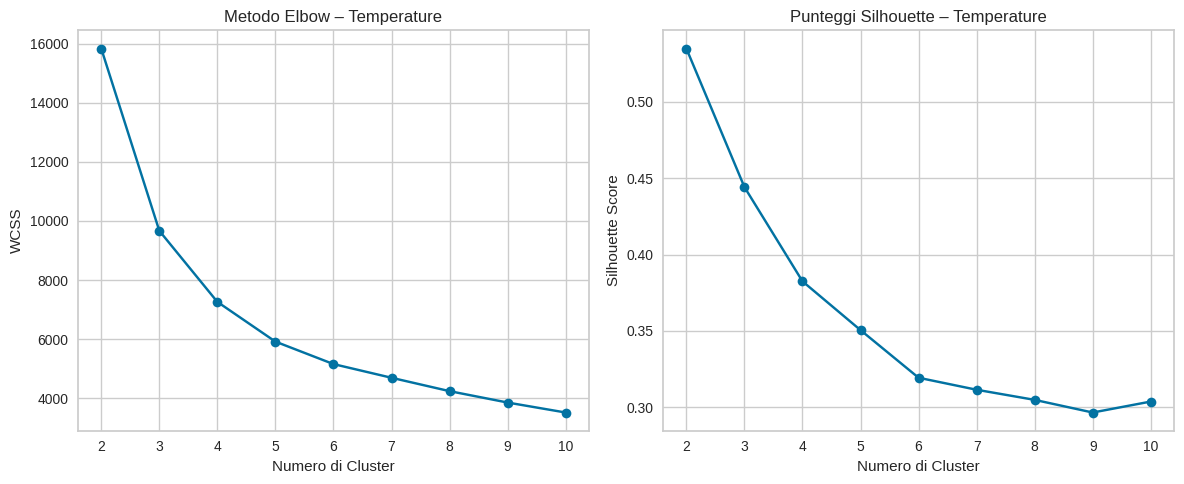


Centroidi Temperature (scala originale):
Cluster 0: max_temp=7.32 °C, mean_temp=3.60 °C, min_temp=0.16 °C
Cluster 1: max_temp=18.06 °C, mean_temp=14.05 °C, min_temp=10.04 °C
Cluster 2: max_temp=23.94 °C, mean_temp=19.10 °C, min_temp=14.18 °C
Cluster 3: max_temp=12.18 °C, mean_temp=8.90 °C, min_temp=5.47 °C


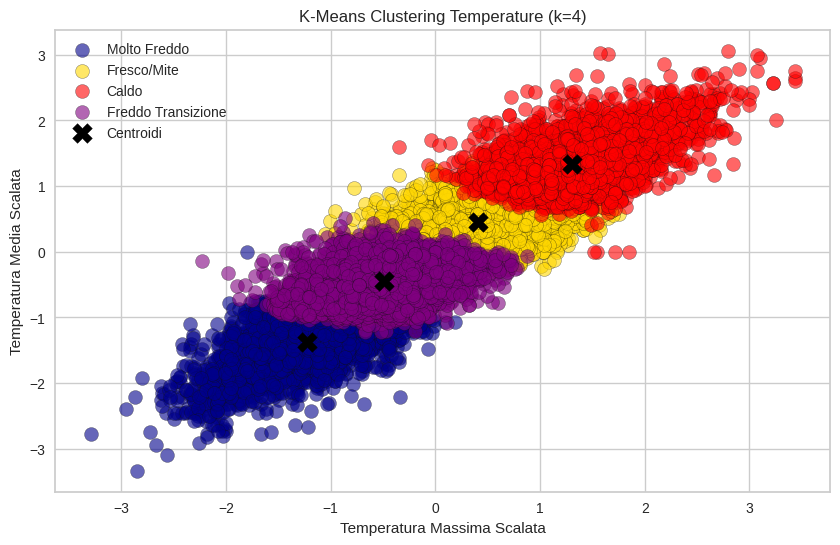

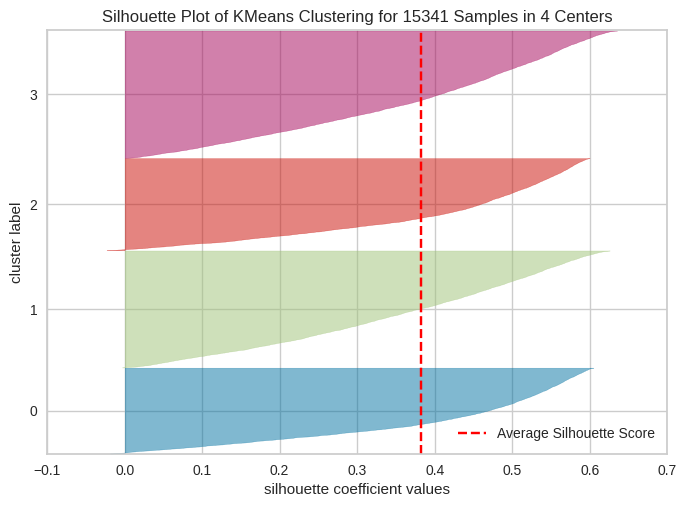


K-Means Temperature - Silhouette: 0.3825
K-Means Temperature - Davies-Bouldin: 0.8281


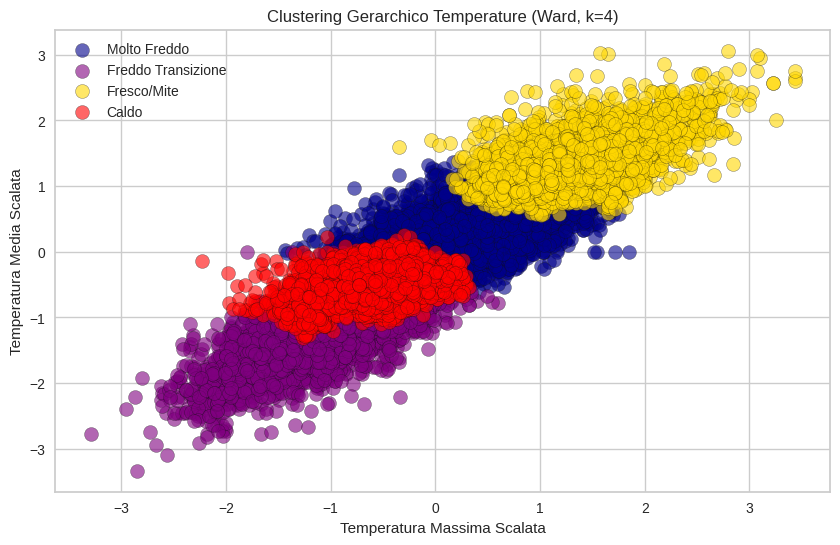

Agglomerative Temperature - Silhouette: 0.3478
Agglomerative Temperature - Davies-Bouldin: 0.8589

Statistiche descrittive Temperature per cluster:
                   max_temp                                               \
                      count       mean       std   min   25%   50%   75%   
temp_cluster_name                                                          
Caldo                3347.0  23.948103  3.296542  13.1  21.5  23.6  26.0   
Freddo Transizione   4627.0  12.180285  2.665223   0.8  10.4  12.2  13.9   
Fresco/Mite          4249.0  18.064499  2.735982   8.5  16.2  18.1  19.9   
Molto Freddo         3118.0   7.315811  3.170463  -6.2   5.1   7.5   9.6   

                         mean_temp             ...                  min_temp  \
                     max     count       mean  ...   75%        max    count   
temp_cluster_name                              ...                             
Caldo               37.9    3347.0  19.101435  ...  20.3  29.000000   3347.0   

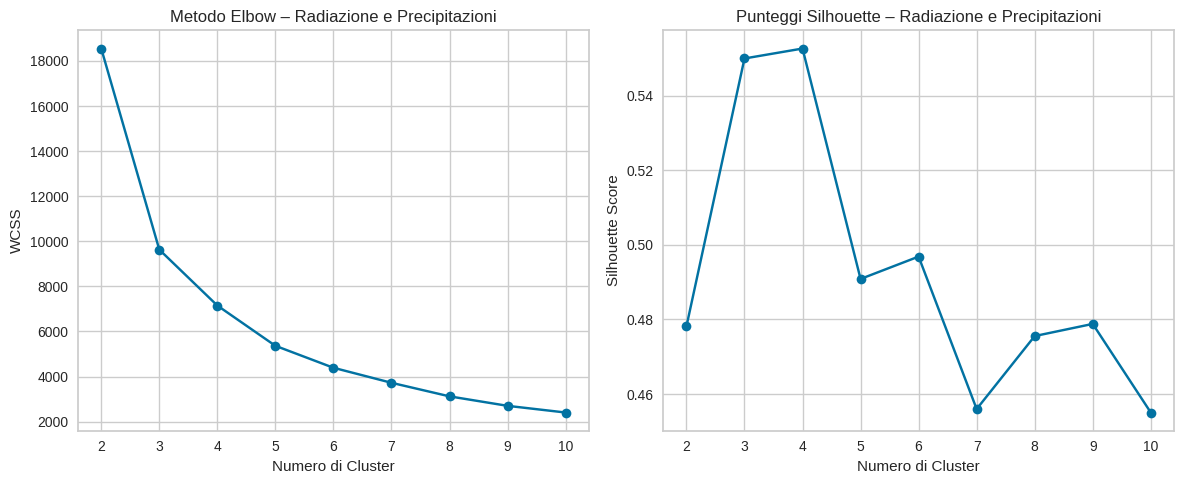


Centroidi Radiazione e Precipitazioni (scala originale):
Cluster 0: global_radiation=73.56 W/m², precipitation=7.49 mm
Cluster 1: global_radiation=224.79 W/m², precipitation=0.44 mm
Cluster 2: global_radiation=62.51 W/m², precipitation=0.61 mm
Cluster 3: global_radiation=82.61 W/m², precipitation=21.14 mm


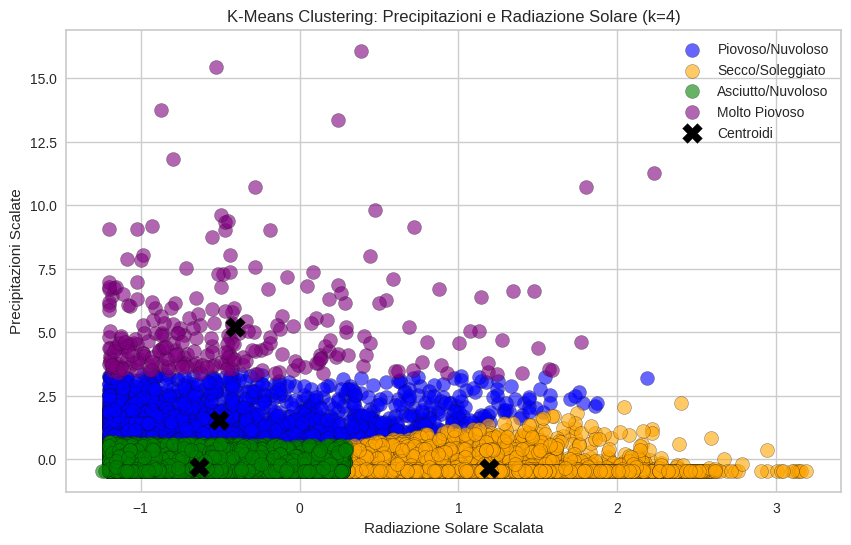

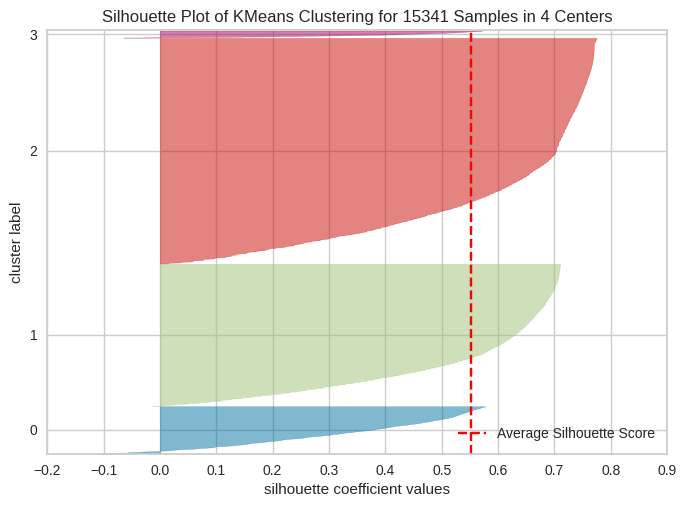


K-Means Rad/Precip - Silhouette: 0.5526
K-Means Rad/Precip - Davies-Bouldin: 0.6698


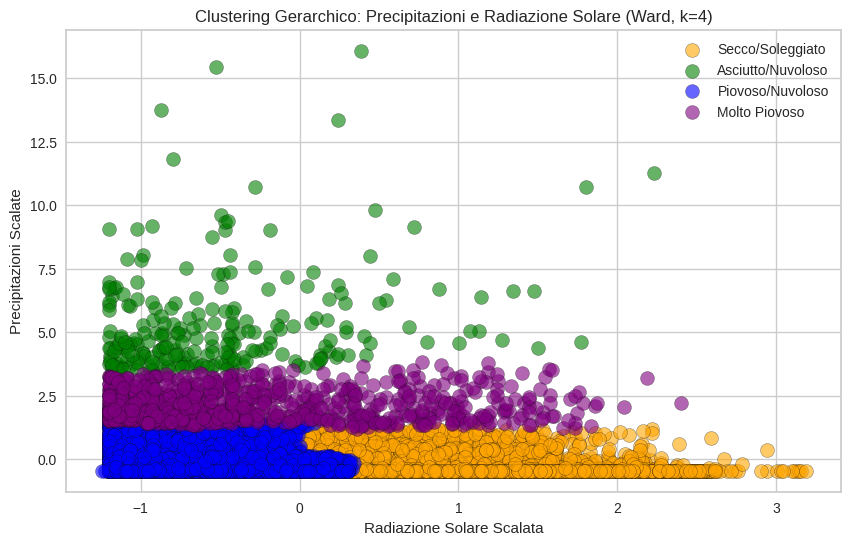

Agglomerative Rad/Precip - Silhouette: 0.5360
Agglomerative Rad/Precip - Davies-Bouldin: 0.7053

Statistiche descrittive Rad/Precip per cluster:
                  global_radiation                                       \
                             count        mean        std    min    25%   
rad_cluster_name                                                          
Asciutto/Nuvoloso           8198.0   62.503462  38.462276    8.0   29.0   
Molto Piovoso                258.0   82.612403  63.479070   12.0   34.0   
Piovoso/Nuvoloso            1717.0   73.620850  58.388380   12.0   26.0   
Secco/Soleggiato            5168.0  224.792183  52.395429  144.0  181.0   

                                       precipitation                       \
                     50%    75%    max         count       mean       std   
rad_cluster_name                                                            
Asciutto/Nuvoloso   55.0   92.0  145.0        8198.0   0.611463  1.008921   
Molto Piovoso       7

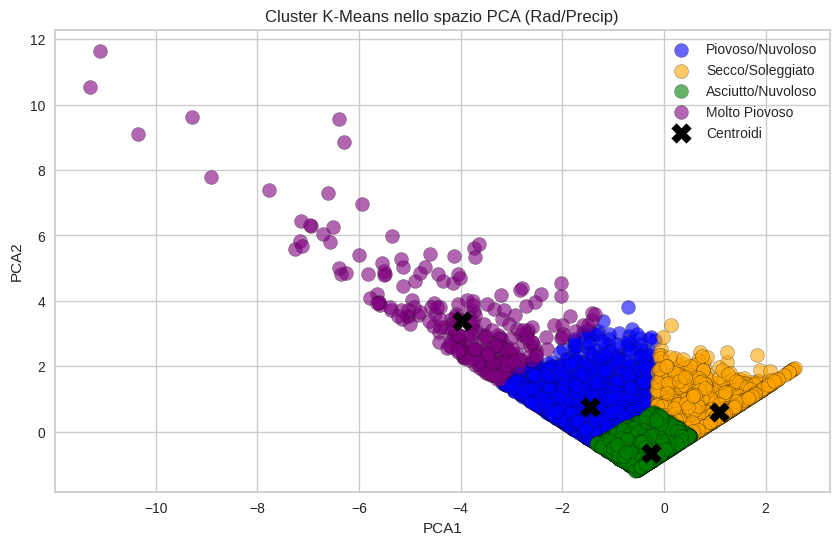

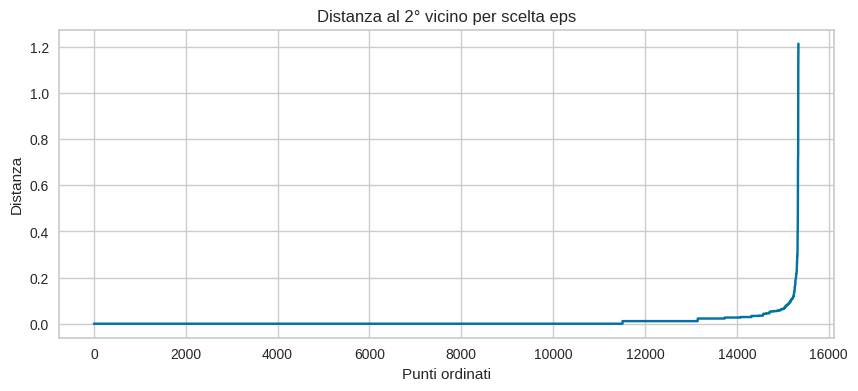


DBSCAN: 3 cluster, 19 punti di rumore


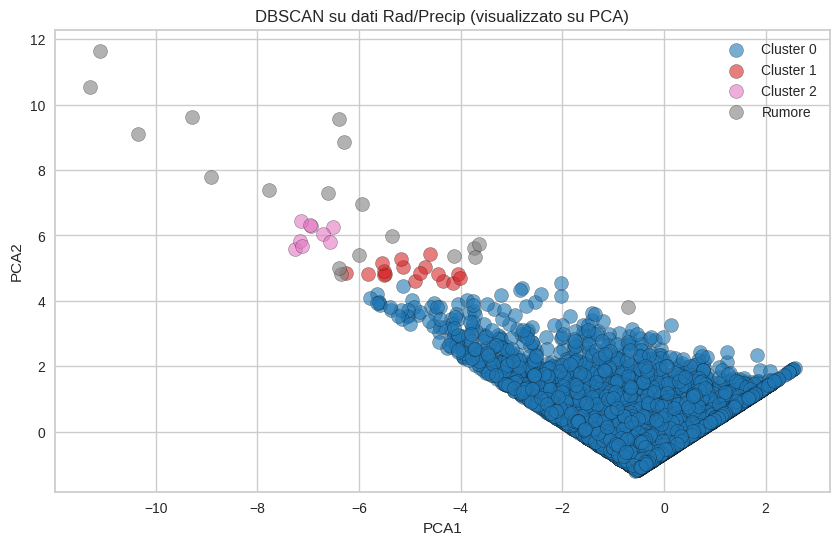


✅ Analisi completata.


In [2]:
# ============================================================================
# Installazione delle librerie necessarie (se non presenti)
# ============================================================================
# !pip install numpy pandas matplotlib seaborn scikit-learn yellowbrick -q

# ============================================================================
# Import delle librerie
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# ============================================================================
# Caricamento e preprocessing del dataset
# ============================================================================
data = pd.read_csv("london_weather.csv", sep=';')

columns_to_fill = [
    "cloud_cover", "sunshine", "global_radiation", "max_temp", "mean_temp",
    "min_temp", "precipitation", "pressure", "snow_depth"
]
for col in columns_to_fill:
    data[col] = data[col].fillna(data[col].mean())

data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')

print("✅ Dataset caricato e preprocessato")
print("Colonne:", data.columns.tolist())
print("Valori mancanti residui:\n", data.isnull().sum())

# ============================================================================
# 1. Clustering delle Temperature
# ============================================================================
x_temp = data[['max_temp', 'mean_temp', 'min_temp']].values

# Standardizzazione
scaler_temp = StandardScaler()
x_temp_scaled = scaler_temp.fit_transform(x_temp)

# Metodo Elbow e Silhouette
wcss_temp = []
sil_scores_temp = []
for i in range(2, 11):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    km.fit(x_temp_scaled)
    wcss_temp.append(km.inertia_)
    labels = km.labels_
    sil_scores_temp.append(silhouette_score(x_temp_scaled, labels))

# Grafici
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), wcss_temp, marker='o')
plt.title('Metodo Elbow – Temperature')
plt.xlabel('Numero di Cluster')
plt.ylabel('WCSS')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), sil_scores_temp, marker='o')
plt.title('Punteggi Silhouette – Temperature')
plt.xlabel('Numero di Cluster')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# K-Means con k=4
km_temp = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_km_temp = km_temp.fit_predict(x_temp_scaled)

# Centroidi in scala originale
centroids_temp_orig = scaler_temp.inverse_transform(km_temp.cluster_centers_)
print("\nCentroidi Temperature (scala originale):")
for i, c in enumerate(centroids_temp_orig):
    print(f"Cluster {i}: max_temp={c[0]:.2f} °C, mean_temp={c[1]:.2f} °C, min_temp={c[2]:.2f} °C")

# Assegnazione automatica dei nomi basata sulla temperatura media
mean_temps = centroids_temp_orig[:, 1]
sorted_idx = np.argsort(mean_temps)  # dal più freddo al più caldo
temp_names = ['Molto Freddo', 'Freddo Transizione', 'Fresco/Mite', 'Caldo']
cluster_to_name_temp = {sorted_idx[i]: temp_names[i] for i in range(4)}

# Colori coerenti
color_map_temp = {
    'Molto Freddo': 'darkblue',
    'Freddo Transizione': 'purple',
    'Fresco/Mite': 'gold',
    'Caldo': 'red'
}

# Visualizzazione K-Means
plt.figure(figsize=(10, 6))
for cluster_id in range(4):
    name = cluster_to_name_temp[cluster_id]
    plt.scatter(x_temp_scaled[y_km_temp == cluster_id, 0],
                x_temp_scaled[y_km_temp == cluster_id, 1],
                s=100, c=color_map_temp[name], label=name, alpha=0.6, edgecolors='k')
plt.scatter(km_temp.cluster_centers_[:, 0], km_temp.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroidi')
plt.title('K-Means Clustering Temperature (k=4)')
plt.xlabel('Temperatura Massima Scalata')
plt.ylabel('Temperatura Media Scalata')
plt.legend()
plt.show()

# Silhouette plot
visualizer_temp = SilhouetteVisualizer(km_temp, colors='yellowbrick')
visualizer_temp.fit(x_temp_scaled)
visualizer_temp.show()

# Metriche
km_sil_temp = silhouette_score(x_temp_scaled, y_km_temp)
km_db_temp = davies_bouldin_score(x_temp_scaled, y_km_temp)
print(f"\nK-Means Temperature - Silhouette: {km_sil_temp:.4f}")
print(f"K-Means Temperature - Davies-Bouldin: {km_db_temp:.4f}")

# Clustering gerarchico
hc_temp = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_hc_temp = hc_temp.fit_predict(x_temp_scaled)

plt.figure(figsize=(10, 6))
for cluster_id in range(4):
    # Utilizziamo gli stessi colori dei nomi; l'ordine potrebbe differire ma visivamente è accettabile
    name = temp_names[cluster_id]  # proviamo ad associare in ordine di visualizzazione
    plt.scatter(x_temp_scaled[y_hc_temp == cluster_id, 0],
                x_temp_scaled[y_hc_temp == cluster_id, 1],
                s=100, c=color_map_temp[name], label=name, alpha=0.6, edgecolors='k')
plt.title('Clustering Gerarchico Temperature (Ward, k=4)')
plt.xlabel('Temperatura Massima Scalata')
plt.ylabel('Temperatura Media Scalata')
plt.legend()
plt.show()

hc_sil_temp = silhouette_score(x_temp_scaled, y_hc_temp)
hc_db_temp = davies_bouldin_score(x_temp_scaled, y_hc_temp)
print(f"Agglomerative Temperature - Silhouette: {hc_sil_temp:.4f}")
print(f"Agglomerative Temperature - Davies-Bouldin: {hc_db_temp:.4f}")

# Statistiche descrittive per LaTeX
data['temp_cluster_name'] = [cluster_to_name_temp[lab] for lab in y_km_temp]
print("\nStatistiche descrittive Temperature per cluster:")
print(data.groupby('temp_cluster_name')[['max_temp', 'mean_temp', 'min_temp']].describe())

# Tabella LaTeX centroidi temperature
print("\n--- Tabella LaTeX Centroidi Temperature ---")
print("\\begin{table}[H]\n\\centering\n\\caption{Centroidi dei cluster di temperatura in scala originale (°C).}\n\\label{tab:centroids_temp}\n\\begin{tabular}{lccc}\n\\hline\n\\textbf{Regime} & \\textbf{max\\_temp} & \\textbf{mean\\_temp} & \\textbf{min\\_temp} \\\\\n\\hline")
for name in temp_names:
    idx = [k for k, v in cluster_to_name_temp.items() if v == name][0]
    c = centroids_temp_orig[idx]
    print(f"{name} & {c[0]:.1f} & {c[1]:.1f} & {c[2]:.1f} \\\\")
print("\\hline\n\\end{tabular}\n\\end{table}")

# ============================================================================
# 2. Clustering Radiazione Solare e Precipitazioni
# ============================================================================
x_rad = data[['global_radiation', 'precipitation']].values
scaler_rad = StandardScaler()
x_rad_scaled = scaler_rad.fit_transform(x_rad)

# Metodo Elbow e Silhouette
wcss_rad = []
sil_scores_rad = []
for i in range(2, 11):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    km.fit(x_rad_scaled)
    wcss_rad.append(km.inertia_)
    sil_scores_rad.append(silhouette_score(x_rad_scaled, km.labels_))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), wcss_rad, marker='o')
plt.title('Metodo Elbow – Radiazione e Precipitazioni')
plt.xlabel('Numero di Cluster')
plt.ylabel('WCSS')
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), sil_scores_rad, marker='o')
plt.title('Punteggi Silhouette – Radiazione e Precipitazioni')
plt.xlabel('Numero di Cluster')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# K-Means con k=4
km_rad = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_km_rad = km_rad.fit_predict(x_rad_scaled)

centroids_rad_orig = scaler_rad.inverse_transform(km_rad.cluster_centers_)
print("\nCentroidi Radiazione e Precipitazioni (scala originale):")
for i, c in enumerate(centroids_rad_orig):
    print(f"Cluster {i}: global_radiation={c[0]:.2f} W/m², precipitation={c[1]:.2f} mm")

# Assegnazione robusta dei nomi ai cluster tramite ordinamento
# Ordiniamo per precipitation crescente, a parità per radiation decrescente
centroids_with_idx = list(enumerate(centroids_rad_orig))
centroids_sorted = sorted(centroids_with_idx, key=lambda x: (x[1][1], -x[1][0]))

rad_names_ordered = ['Secco/Soleggiato', 'Asciutto/Nuvoloso', 'Piovoso/Nuvoloso', 'Molto Piovoso']
# Creiamo un mapping: indice originale -> nome
cluster_to_name_rad = {}
for (orig_idx, _), name in zip(centroids_sorted, rad_names_ordered):
    cluster_to_name_rad[orig_idx] = name

color_map_rad = {
    'Secco/Soleggiato': 'orange',
    'Asciutto/Nuvoloso': 'green',
    'Piovoso/Nuvoloso': 'blue',
    'Molto Piovoso': 'purple'
}

# Visualizzazione
plt.figure(figsize=(10, 6))
for cluster_id in range(4):
    name = cluster_to_name_rad[cluster_id]
    plt.scatter(x_rad_scaled[y_km_rad == cluster_id, 0],
                x_rad_scaled[y_km_rad == cluster_id, 1],
                s=100, c=color_map_rad[name], label=name, alpha=0.6, edgecolors='k')
plt.scatter(km_rad.cluster_centers_[:, 0], km_rad.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroidi')
plt.title('K-Means Clustering: Precipitazioni e Radiazione Solare (k=4)')
plt.xlabel('Radiazione Solare Scalata')
plt.ylabel('Precipitazioni Scalate')
plt.legend()
plt.show()

# Silhouette plot
visualizer_rad = SilhouetteVisualizer(km_rad, colors='yellowbrick')
visualizer_rad.fit(x_rad_scaled)
visualizer_rad.show()

# Metriche
km_sil_rad = silhouette_score(x_rad_scaled, y_km_rad)
km_db_rad = davies_bouldin_score(x_rad_scaled, y_km_rad)
print(f"\nK-Means Rad/Precip - Silhouette: {km_sil_rad:.4f}")
print(f"K-Means Rad/Precip - Davies-Bouldin: {km_db_rad:.4f}")

# Clustering gerarchico
hc_rad = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_hc_rad = hc_rad.fit_predict(x_rad_scaled)

plt.figure(figsize=(10, 6))
for cluster_id in range(4):
    name = rad_names_ordered[cluster_id]  # associazione visiva
    plt.scatter(x_rad_scaled[y_hc_rad == cluster_id, 0],
                x_rad_scaled[y_hc_rad == cluster_id, 1],
                s=100, c=color_map_rad[name], label=name, alpha=0.6, edgecolors='k')
plt.title('Clustering Gerarchico: Precipitazioni e Radiazione Solare (Ward, k=4)')
plt.xlabel('Radiazione Solare Scalata')
plt.ylabel('Precipitazioni Scalate')
plt.legend()
plt.show()

hc_sil_rad = silhouette_score(x_rad_scaled, y_hc_rad)
hc_db_rad = davies_bouldin_score(x_rad_scaled, y_hc_rad)
print(f"Agglomerative Rad/Precip - Silhouette: {hc_sil_rad:.4f}")
print(f"Agglomerative Rad/Precip - Davies-Bouldin: {hc_db_rad:.4f}")

# Statistiche descrittive
data['rad_cluster_name'] = [cluster_to_name_rad[lab] for lab in y_km_rad]
print("\nStatistiche descrittive Rad/Precip per cluster:")
print(data.groupby('rad_cluster_name')[['global_radiation', 'precipitation']].describe())

# Tabella LaTeX centroidi
print("\n--- Tabella LaTeX Centroidi Rad/Precip ---")
print("\\begin{table}[H]\n\\centering\n\\caption{Centroidi dei cluster per radiazione e precipitazioni (unità originali).}\n\\label{tab:centroids_rad}\n\\begin{tabular}{lcc}\n\\hline\n\\textbf{Regime} & \\textbf{global\\_radiation (W/m²)} & \\textbf{precipitation (mm)} \\\\\n\\hline")
for name in rad_names_ordered:
    # trova l'indice originale corrispondente
    orig_idx = [k for k, v in cluster_to_name_rad.items() if v == name][0]
    c = centroids_rad_orig[orig_idx]
    print(f"{name} & {c[0]:.1f} & {c[1]:.2f} \\\\")
print("\\hline\n\\end{tabular}\n\\end{table}")

# Tabella LaTeX statistiche descrittive (esempio con media)
print("\n--- Tabella LaTeX Statistiche Descrittive Rad/Precip (media ± std) ---")
print("\\begin{table}[H]\n\\centering\n\\caption{Statistiche descrittive medie (media $\\pm$ deviazione standard) per ciascun regime di radiazione e precipitazioni.}\n\\label{tab:desc_rad}\n\\begin{tabular}{lcccc}\n\\hline\n\\textbf{Regime} & \\textbf{Radiazione (W/m²)} & \\textbf{Precipitazione (mm)} & \\textbf{Conteggio} \\\\\n\\hline")
for name in rad_names_ordered:
    subset = data[data['rad_cluster_name'] == name]
    cnt = len(subset)
    mu_rad = subset['global_radiation'].mean()
    std_rad = subset['global_radiation'].std()
    mu_prec = subset['precipitation'].mean()
    std_prec = subset['precipitation'].std()
    print(f"{name} & ${mu_rad:.1f} \\pm {std_rad:.1f}$ & ${mu_prec:.2f} \\pm {std_prec:.2f}$ & {cnt} \\\\")
print("\\hline\n\\end{tabular}\n\\end{table}")

# ============================================================================
# 3. PCA e DBSCAN (su dati Radiazione/Precipitazioni)
# ============================================================================
pca = PCA(n_components=2)
pca_rad_scaled = pca.fit_transform(x_rad_scaled)

# Visualizzazione K-Means nello spazio PCA
plt.figure(figsize=(10, 6))
for cluster_id in range(4):
    name = cluster_to_name_rad[cluster_id]
    plt.scatter(pca_rad_scaled[y_km_rad == cluster_id, 0],
                pca_rad_scaled[y_km_rad == cluster_id, 1],
                s=100, c=color_map_rad[name], label=name, alpha=0.6, edgecolors='k')
centers_pca = pca.transform(km_rad.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], s=200, c='black', marker='X', label='Centroidi')
plt.title('Cluster K-Means nello spazio PCA (Rad/Precip)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.show()

# DBSCAN
neigh = NearestNeighbors(n_neighbors=2)
neigh.fit(x_rad_scaled)
distances, _ = neigh.kneighbors(x_rad_scaled)
distances = np.sort(distances[:, 1])
plt.figure(figsize=(10, 4))
plt.plot(distances)
plt.title('Distanza al 2° vicino per scelta eps')
plt.xlabel('Punti ordinati')
plt.ylabel('Distanza')
plt.show()

# Impostiamo eps basandoci sul ginocchio (0.5 circa)
db = DBSCAN(eps=0.5, min_samples=5)
y_db = db.fit_predict(x_rad_scaled)
n_clusters_db = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise = list(y_db).count(-1)
print(f"\nDBSCAN: {n_clusters_db} cluster, {n_noise} punti di rumore")

# Visualizzazione DBSCAN su PCA
plt.figure(figsize=(10, 6))
unique_labels = set(y_db)
colors_db = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for k, col in zip(unique_labels, colors_db):
    if k == -1:
        col = [0.5, 0.5, 0.5, 1]  # grigio per il rumore
    mask = (y_db == k)
    plt.scatter(pca_rad_scaled[mask, 0], pca_rad_scaled[mask, 1],
                s=100, color=col, label=f'Cluster {k}' if k != -1 else 'Rumore',
                alpha=0.6, edgecolors='k')
plt.title('DBSCAN su dati Rad/Precip (visualizzato su PCA)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.show()

print("\n✅ Analisi completata.")